# Bitcoin Market Sentiment vs Trader Performance Analysis

Round-0 Assignment for Primetrade.ai

Author: Varad Sanjay Arsude

## Introduction

This project analyzes the relationship between Bitcoin Fear & Greed Index and historical Hyperliquid trader performance. The objective is to understand how market sentiment influences trading profitability, trading activity, and trader behavior.

## Dataset Description

Dataset 1:
Historical Hyperliquid Trader Data
- Account
- Coin
- Execution Price
- Size
- Fee
- Closed PnL
- Timestamp

Dataset 2:
Bitcoin Fear & Greed Index
- Date
- Sentiment Classification
- Index Value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [2]:
hist = pd.read_csv("historical_data.csv")
fg = pd.read_csv("fear_greed_index.csv")

hist.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print(hist.columns)
print(fg.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [5]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:

hist["date"] = pd.to_datetime(
    hist["Timestamp IST"],
    dayfirst=True
).dt.date


fg["date"] = pd.to_datetime(
    fg["date"]
).dt.date

In [8]:
hist[["Timestamp IST","date"]].head()

,Timestamp IST,date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [9]:
df = hist.merge(
    fg[["date","classification","value"]],
    on="date",
    how="left"
)

In [10]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [11]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      6
value               6
dtype: int64

## Analysis 1: Average Closed PnL by Market Sentiment

This analysis measures the average trader profit under each market sentiment category.

In [12]:
avg_pnl = df.groupby("classification")["Closed PnL"].mean()

avg_pnl

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

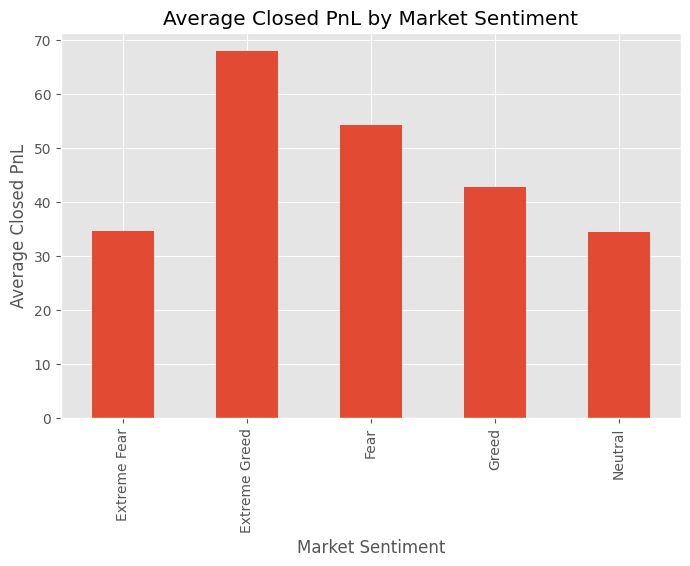

In [13]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Average Closed PnL")

plt.show()

### Observation

- Extreme Greed has the highest average trader profitability.
- Fear also performs relatively well.
- Neutral and Extreme Fear show comparatively lower profits.

## Analysis 2: Number of Trades by Market Sentiment

This analysis measures how many trades were executed under each market sentiment category.

In [14]:
trade_count = df["classification"].value_counts()

trade_count

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

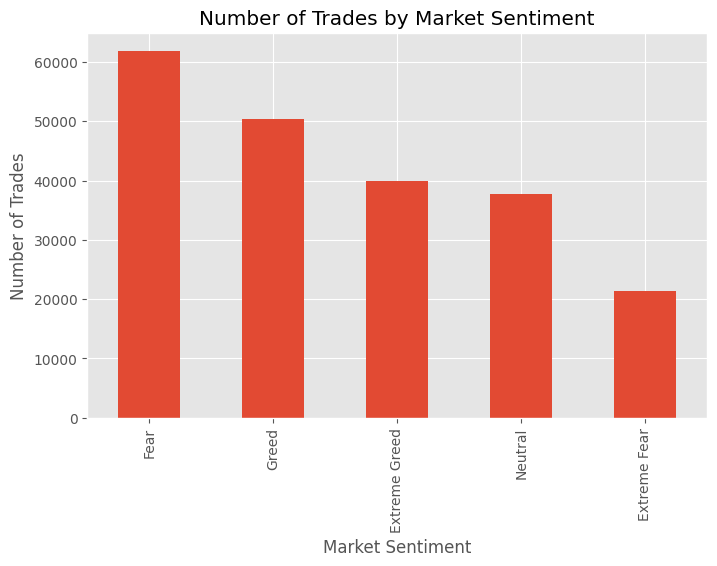

In [15]:
plt.figure(figsize=(8,5))

trade_count.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")

plt.show()

### Observation

- The distribution of trades varies across different market sentiments.
- Some sentiment categories have significantly higher trading activity.

## Analysis 3: Average Trading Fee by Market Sentiment

This analysis compares the average trading fee under different market sentiment categories.

In [16]:
avg_fee = df.groupby("classification")["Fee"].mean()

avg_fee

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

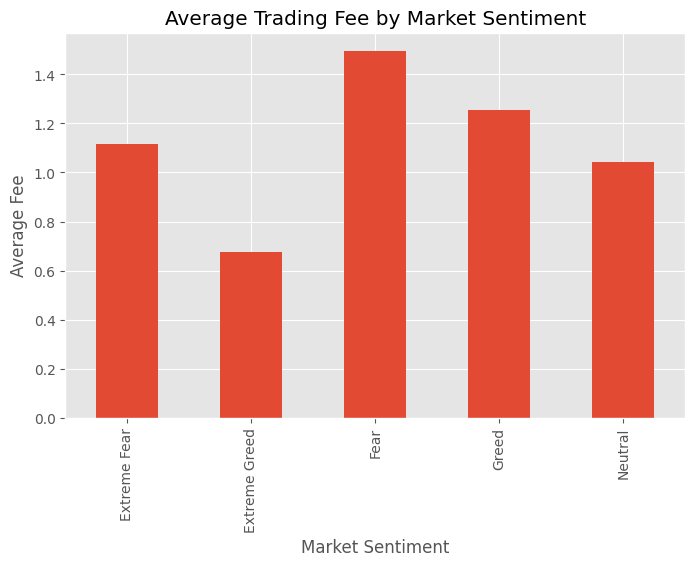

In [17]:
plt.figure(figsize=(8,5))

avg_fee.plot(kind="bar")

plt.title("Average Trading Fee by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Average Fee")

plt.show()

### Observation

- Trading fees vary across different market sentiment categories.
- Higher trading activity generally leads to higher average fees.

## Analysis 4: Top 10 Coins by Average Closed PnL

This analysis identifies the top-performing cryptocurrencies based on average closed profit.

In [18]:
coin_profit = df.groupby("Coin")["Closed PnL"].mean()

coin_profit = coin_profit.sort_values(ascending=False).head(10)

coin_profit

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64

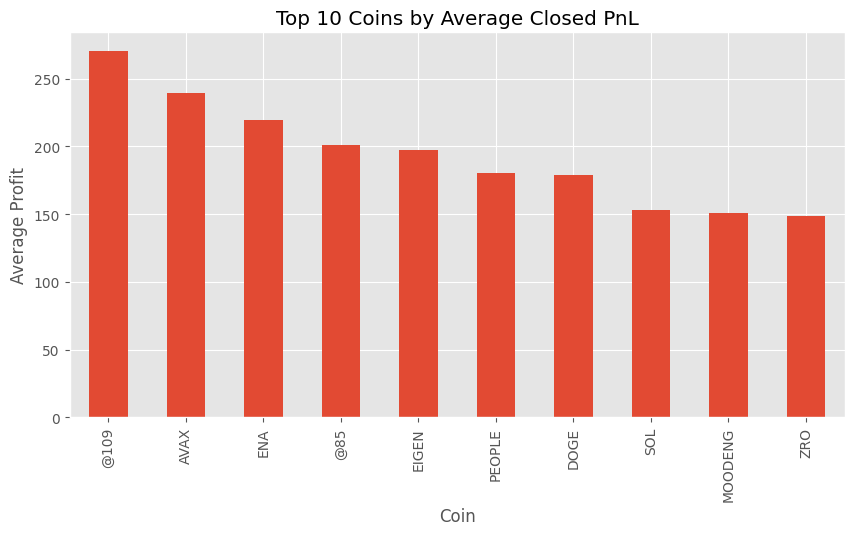

In [19]:
plt.figure(figsize=(10,5))

coin_profit.plot(kind="bar")

plt.title("Top 10 Coins by Average Closed PnL")

plt.ylabel("Average Profit")

plt.show()

### Observation

- A small number of coins consistently generated higher profits.
- These coins outperformed the remaining cryptocurrencies.

## Analysis 5: Buy vs Sell Distribution

This analysis shows the proportion of Buy and Sell trades.

In [20]:
direction = df["Direction"].value_counts()

direction

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

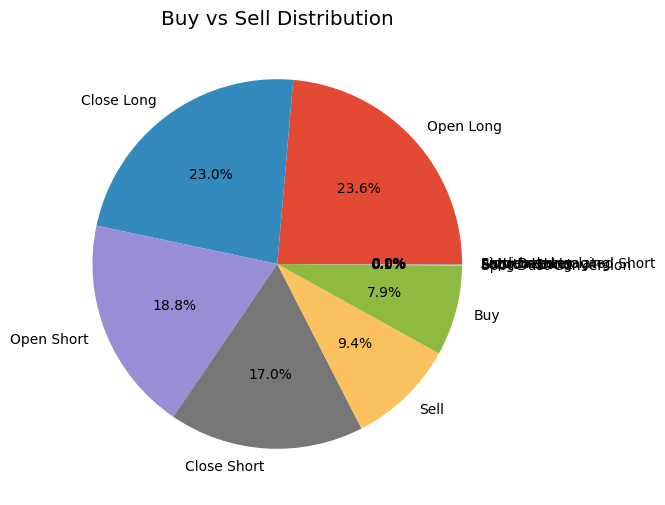

In [21]:
plt.figure(figsize=(6,6))

direction.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Buy vs Sell Distribution")

plt.show()

### Observation

- The chart shows the percentage of Buy and Sell trades.
- This helps understand overall trader positioning.

## Analysis 6: Top 10 Traders by Total Closed PnL

This analysis identifies the traders with the highest cumulative profit.

In [22]:
top_traders = (
    df.groupby("Account")["Closed PnL"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

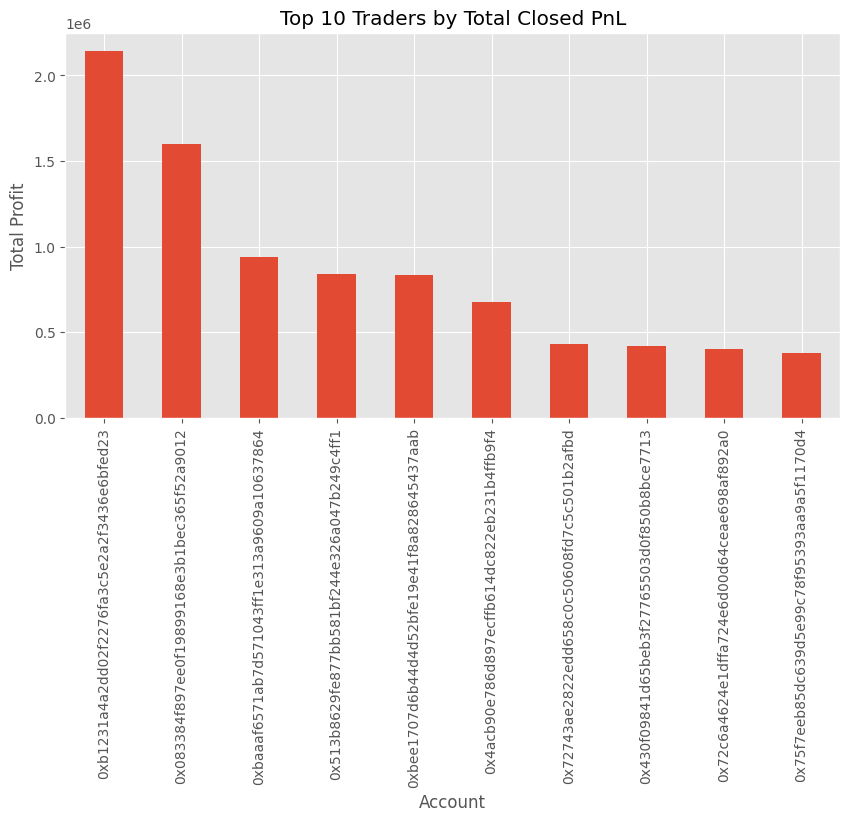

In [23]:
plt.figure(figsize=(10,5))

top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Total Closed PnL")

plt.ylabel("Total Profit")

plt.show()

### Observation

- A few traders generated significantly higher profits than others.
- Profit distribution among traders is highly uneven.

## Conclusion

This project analyzed the relationship between Bitcoin Fear & Greed Index and historical Hyperliquid trader performance.

### Key Findings

- Traders achieved the highest average Closed PnL during **Extreme Greed** market conditions.
- Trading activity varied significantly across different market sentiments.
- Trading fees also changed depending on market sentiment.
- Some cryptocurrencies consistently produced higher average profits than others.
- A small number of traders generated a large share of the overall profits.

### Overall Conclusion

The analysis suggests that market sentiment has a noticeable influence on trader behavior and trading performance. These insights can help traders and analysts better understand how emotions in the cryptocurrency market affect profitability and decision-making.